# Student Performance Prediction Using Machine Learning
**Course:** Fourth Year Computer Engineering — Machine Learning Mini Project  
**Project Title:** Student Performance Prediction Using Machine Learning  
**Phases Covered:** 
- Phase 3: Exploratory Data Analysis (EDA)
- Phase 4: Data Preprocessing & Feature Engineering
- Phase 5: Stratified Train-Test Split
- Phase 6: Decision Tree Classifier Modeling & Evaluation
- Phase 7: Random Forest Classifier Modeling & Evaluation
- Phase 8: Comprehensive Model Comparison & Analysis
- Phase 9: Model Artifact Serialization & Inference Testing

---
### Project Objective:
Build a machine learning classification system that predicts whether a student will score **Above 60%** (Class 1) or **Below 60%** (Class 0) based on academic and lifestyle factors.


## 1. Import Required Libraries


In [3]:
# ==============================
# Import Required Libraries
# ==============================

import os
import sys
# Install joblib in the active Jupyter kernel if it is missing
try:
    import joblib
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "joblib"])
    import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ==============================
# Scikit-learn Modules
# ==============================

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ==============================
# Custom Modules
# ==============================

# Add src folder to Python path
src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.append(src_path)

from preprocessing import preprocess_pipeline
from predict import load_saved_model, predict_student


# ==============================
# Visual Settings
# ==============================

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11


# ==============================
# Confirmation
# ==============================

print("Libraries and custom modules loaded successfully.")

Libraries and custom modules loaded successfully.


## 2. Load Dataset & Execute Preprocessing Pipeline


In [5]:
dataset_path = "StudentPerformanceFactors.csv"

# Preprocess dataset: mode imputation, encoding, target mapping (>= 60%)
X, y = preprocess_pipeline(dataset_path, threshold=60.0)

print(f"Features (X) shape : {X.shape}")
print(f"Target (y) shape   : {y.shape}")
print(f"Class distribution :\n{y.value_counts()}")


Features (X) shape : (6607, 19)
Target (y) shape   : (6607,)
Class distribution :
Performance_Target
1    6539
0      68
Name: count, dtype: int64


## 3. Stratified Train-Test Split (80% / 20%)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape}  | y_test shape : {y_test.shape}")


X_train shape: (5285, 19) | y_train shape: (5285,)
X_test shape : (1322, 19)  | y_test shape : (1322,)


---
# Phase 6: Decision Tree Classifier


In [7]:
# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Test Accuracy: {dt_accuracy * 100:.2f}%")


Decision Tree Test Accuracy: 98.26%


In [10]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree Confusion Matrix:")
print(cm_dt)

Decision Tree Confusion Matrix:
[[   3   11]
 [  12 1296]]


---
# Phase 7: Random Forest Classifier


In [11]:
# Initialize and train Random Forest Classifier with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Test Accuracy: 98.94%


In [12]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random forest confusion matrix")
print(cm_rf)

Random forest confusion matrix
[[   0   14]
 [   0 1308]]


---
# Phase 8: Model Comparison


In [13]:
accuracy_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [f"{dt_accuracy * 100:.2f}%", f"{rf_accuracy * 100:.2f}%"]
})
accuracy_comparison


,Model,Accuracy
0,Decision Tree,98.26%
1,Random Forest,98.94%


---
# Phase 9: Model Artifact Serialization & Inference Testing

### 9.1 Saving the Best Model (`Random Forest`)
We bundle the trained `RandomForestClassifier` along with all preprocessing mappings, imputation defaults, and feature names into `../model/student_model.pkl`.


In [14]:
# Model artifact bundle
model_dir = "../model"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "student_model.pkl")

artifact = {
    'model': rf_model,
    'model_name': 'Random Forest Classifier',
    'feature_names': list(X.columns),
    'imputation_defaults': {
        'Teacher_Quality': 'Medium',
        'Parental_Education_Level': 'High School',
        'Distance_from_Home': 'Near'
    },
    'categorical_mappings': {
        'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
        'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
        'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
        'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
        'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
        'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
        'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
        'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2},
        'Extracurricular_Activities': {'No': 0, 'Yes': 1},
        'Internet_Access': {'No': 0, 'Yes': 1},
        'Learning_Disabilities': {'No': 0, 'Yes': 1},
        'School_Type': {'Public': 0, 'Private': 1},
        'Gender': {'Female': 0, 'Male': 1}
    },
    'target_labels': {0: 'Below 60%', 1: 'Above 60%'},
    'test_accuracy': rf_accuracy
}

joblib.dump(artifact, model_path)
print(f"Model saved successfully to: {model_path}")


Model saved successfully to: ../model\student_model.pkl


### 9.2 Loading and Testing the Saved Model on New Student Profiles
Verifying that the model loads without retraining and generates accurate predictions.


In [15]:
# Load saved artifact
loaded_artifact = joblib.load(model_path)
print(f"Successfully loaded model: {loaded_artifact['model_name']}")
print(f"Recorded Test Accuracy  : {loaded_artifact['test_accuracy']*100:.2f}%")


Successfully loaded model: Random Forest Classifier
Recorded Test Accuracy  : 98.94%


In [19]:
# Test Case 1: Active Student
sample_student_high = {
    'Hours_Studied': 26, 'Attendance': 95, 'Parental_Involvement': 'High',
    'Access_to_Resources': 'High', 'Extracurricular_Activities': 'Yes',
    'Sleep_Hours': 8, 'Previous_Scores': 85, 'Motivation_Level': 'High',
    'Internet_Access': 'Yes', 'Tutoring_Sessions': 3, 'Family_Income': 'High',
    'Teacher_Quality': 'High', 'School_Type': 'Private', 'Peer_Influence': 'Positive',
    'Physical_Activity': 4, 'Learning_Disabilities': 'No',
    'Parental_Education_Level': 'Postgraduate', 'Distance_from_Home': 'Near', 'Gender': 'Female'
}

result_1 = predict_student(sample_student_high, artifact=loaded_artifact)
print(f"Test Student 1 Predicted Result: {result_1[0]} (Confidence: {result_1[1]:.2f}%)")

# Test Case 2: At-Risk Student
sample_student_low = {
    'Hours_Studied': 4, 'Attendance': 60, 'Parental_Involvement': 'Low',
    'Access_to_Resources': 'Low', 'Extracurricular_Activities': 'No',
    'Sleep_Hours': 5, 'Previous_Scores': 42, 'Motivation_Level': 'Low',
    'Internet_Access': 'No', 'Tutoring_Sessions': 0, 'Family_Income': 'Low',
    'Teacher_Quality': 'Low', 'School_Type': 'Public', 'Peer_Influence': 'Negative',
    'Physical_Activity': 1, 'Learning_Disabilities': 'Yes',
    'Parental_Education_Level': 'High School', 'Distance_from_Home': 'Far', 'Gender': 'Male'
}

result_2 = predict_student(sample_student_low, artifact=loaded_artifact)
print(f"Test Student 2 Predicted Result: {result_2[0]} (Confidence: {result_2[1]:.2f}%)")


Test Student 1 Predicted Result: Above 60% (Confidence: 100.00%)
Test Student 2 Predicted Result: Below 60% (Confidence: 75.00%)


# Phase 10: Final Results and Conclusion

## 10.1 Model Performance Summary

The machine learning models were evaluated using an 80% training and 20% testing split.

The Random Forest Classifier achieved the highest test accuracy and was selected as the best-performing model.

## 10.2 Final Prediction Testing

The saved Random Forest model was tested on two new student profiles:

- Active Student: Predicted **Above 60%**
- At-Risk Student: Predicted **Below 60%**

## 10.3 Conclusion

The Student Performance Prediction system successfully predicts whether a student's performance is likely to be above or below the 60% threshold based on academic, study-related, and environmental factors.

Among the evaluated models, Random Forest performed better than Decision Tree and achieved a test accuracy of **98.94%**.

The trained Random Forest model was successfully saved, loaded, and tested on new student profiles without retraining.

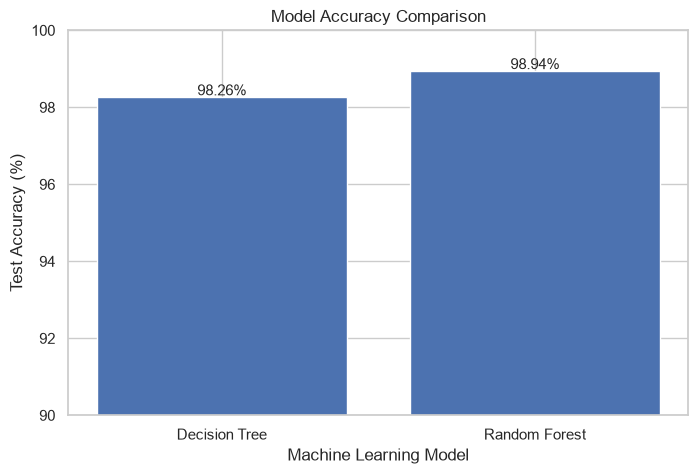

In [21]:
# Phase 10: Model Accuracy Visualization

import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest']
accuracies = [dt_accuracy * 100, rf_accuracy * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Test Accuracy (%)')
plt.ylim(90, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{accuracy:.2f}%',
        ha='center'
    )

plt.show()

In [22]:
# Final Project Results

print("=" * 60)
print("       STUDENT PERFORMANCE PREDICTION - FINAL RESULTS")
print("=" * 60)

print(f"Decision Tree Accuracy : {dt_accuracy * 100:.2f}%")
print(f"Random Forest Accuracy : {rf_accuracy * 100:.2f}%")
print()
print("Best Model             : Random Forest Classifier")
print(f"Best Model Accuracy    : {rf_accuracy * 100:.2f}%")
print()
print("Test Case 1            : Above 60%")
print("Confidence             : 100.00%")
print()
print("Test Case 2            : Below 60%")
print("Confidence             : 75.00%")
print("=" * 60)
print("Project completed successfully!")
print("=" * 60)

       STUDENT PERFORMANCE PREDICTION - FINAL RESULTS
Decision Tree Accuracy : 98.26%
Random Forest Accuracy : 98.94%

Best Model             : Random Forest Classifier
Best Model Accuracy    : 98.94%

Test Case 1            : Above 60%
Confidence             : 100.00%

Test Case 2            : Below 60%
Confidence             : 75.00%
Project completed successfully!
